In [41]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[2]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [42]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
import numpy as np

from clonalg.antibody.real_antibody import RealAntibody, RealAntibodyBuilder
from clonalg.model.clonalg_optimization import OptimizationClonalg
from clonalg.problems.problem import Rastrigin
from clonalg.problems.visualization import plot_3d_surface, plot_contour_and_paths

In [44]:
rastrigin = Rastrigin()
n_dims = 2
bounds = [(-5.0, 5.0)] * n_dims

def factory() -> RealAntibody:
    genes = np.array([np.random.uniform(lo, hi) for lo, hi in bounds])
    return (
        RealAntibodyBuilder()
        .with_genes(genes)
        .with_bounds(bounds)
        .with_distance_fn(lambda a, b: rastrigin(a))  # b ignored, affinity = 1 / (1 + f(a))
        .build()
    )

clonalg = OptimizationClonalg(
    population_size=20,
    clone_factor=0.2,
    n_replace=5,
    n_generations=1000,
    antibody_factory=factory,
)

memory = clonalg.run()
memory.sort(key=lambda ab: ab.affinity(None), reverse=True)

In [45]:
best = memory[0]
paths = list(map(lambda x: np.array(x.genes).reshape(1, 2), memory))

print(f"Best solution: x = {best.genes}")
print(f"f(x)         = {rastrigin(best.genes):.6f}")
print(f"affinity     = {best.affinity(None):.6f}")

Best solution: x = [1.89116249e-05 1.29181447e-02]
f(x)         = 0.033089
affinity     = 0.967970


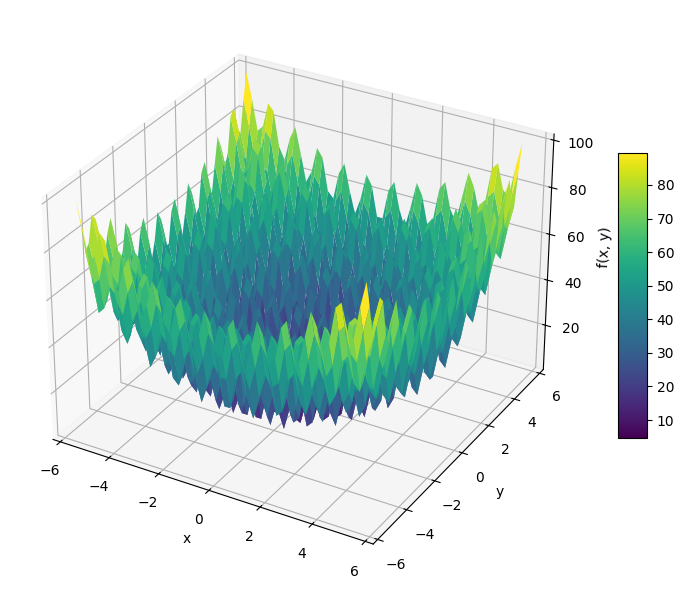

In [46]:
plot_3d_surface(rastrigin)
plot_contour_and_paths(rastrigin, paths)